## 1. Imports & Setup

imported all required libraries upfront for clarity:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualisation
- **sklearn** — preprocessing, modelling, evaluation
- **lightgbm** — model machine learning
- **re / string** — regex & text cleaning 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import lightgbm as lgb
import re
import string

## 2. Data Loading

Three CSV files are loaded:
- **sample.csv** — submission file
- **train.csv** — labelled comments for model training
- **test.csv** — unlabelled comments for final prediction


In [ ]:
sample = pd.read_csv("comment-category-prediction-challenge/Sample.csv")
train = pd.read_csv("category-prediction-challenge/train.csv")
test= pd.read_csv("category-prediction-challenge/test.csv")

In [4]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [5]:
print(train.shape)
print(test.shape)
print(sample.shape)

(198000, 15)
(102000, 14)
(102000, 2)


## 3. Exploratory Data Analysis (EDA)

Before modelling, to understand the data systematicallly 
1. **Feature types** — numerical, categorical, text, datetime
2. **Target distribution** — class balance
3. **Comment length** — text signal quality
4. **Vote patterns** — community engagement signals
5. **Sensitivity flags** — race / religion / gender mentions

In [6]:
# Feature Type Identification 

print("Numerical Features:")
print(train.select_dtypes(include=['int64','float64']).columns.tolist())

print("\nCategorical / Text Features:")
print(train.select_dtypes(include=['object']).columns.tolist())

print("\nDatetime Features:")
print(train.select_dtypes(include=['datetime64']).columns.tolist())

print("\nTarget Variable:")
print('label')

Numerical Features:
['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']

Categorical / Text Features:
['created_date', 'race', 'religion', 'gender', 'comment']

Datetime Features:
[]

Target Variable:
label


## 4. Check for missing values

### solution
| Column | Issue | Fix |
|--------|-------|-----|
| `comment` | 1 missing row | Droping the row |
| `race`, `religion`, `gender` | NaN = "not mentioned" | Convert to binary flag: `1` if present, `0` if Not present |
| `disability` | Boolean stored as object | Casting to int |



In [7]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [ ]:
# Drop only 1 missing comment row
train = train.dropna(subset=['comment'])

# Convert NaN to 0/1 for sensitive columns
for col in ['race', 'religion', 'gender']:
    train[col] = train[col].notna().astype(int)
    test[col] = test[col].notna().astype(int)

# Convert boolean
train['disability'] = train['disability'].astype(int)
test['disability'] = test['disability'].astype(int)

train.isnull().sum()

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
label           0
dtype: int64

In [9]:
train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race             int64
religion         int64
gender           int64
disability       int64
comment         object
label            int64
dtype: object

## 5.  Datetime Feature Extraction

The `created_date` column is parsed to extract the **hour of the day**.  
Online comment toxicity can be time-dependent (for example late-night comments may be more aggressive because people might have more free time in hand).  


In [10]:
# Date Features
train['created_date'] = pd.to_datetime(train['created_date'])
test['created_date'] = pd.to_datetime(test['created_date'])

train['hour'] = train['created_date'].dt.hour
test['hour'] = test['created_date'].dt.hour

/tmp/ipykernel_17/634451154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train, palette='viridis')


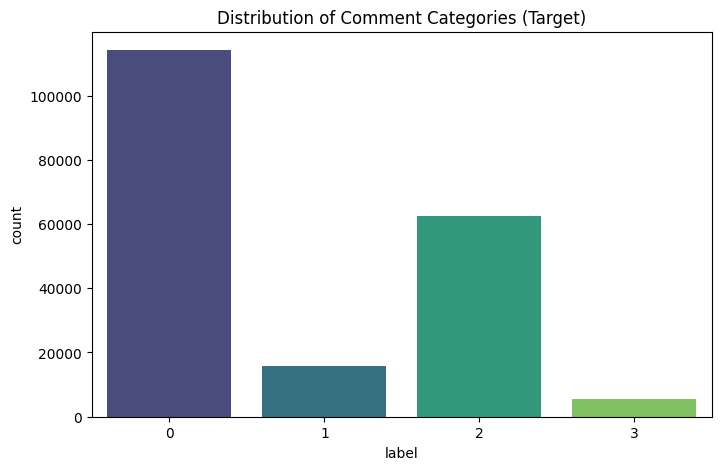

In [11]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train, palette='viridis')
plt.title('Distribution of Comment Categories (Target)')
plt.show()

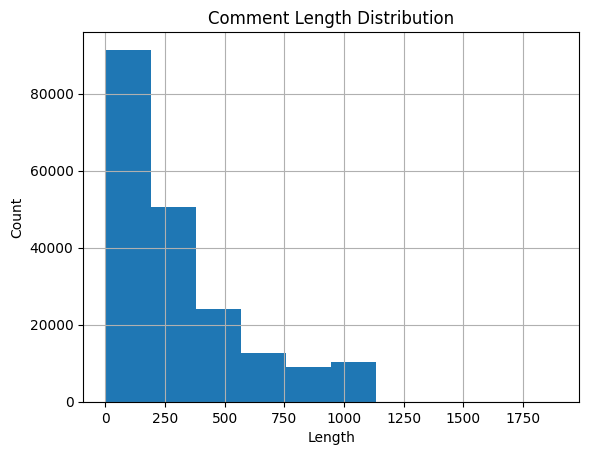

In [12]:
train['comment_length'] = train['comment'].astype(str).apply(len)

train['comment_length'].hist()
plt.title("Comment Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

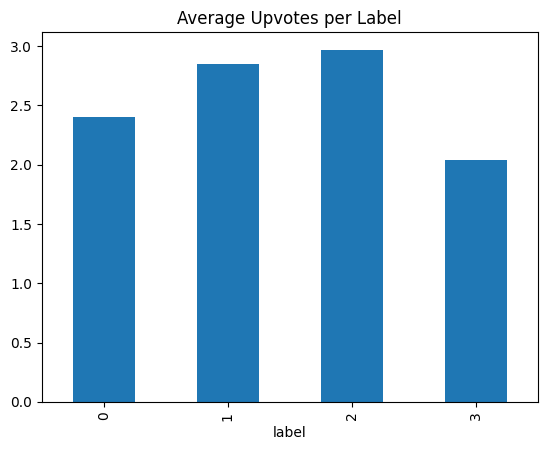

In [13]:
train.groupby('label')['upvote'].mean().plot(kind='bar')
plt.title("Average Upvotes per Label")
plt.show()

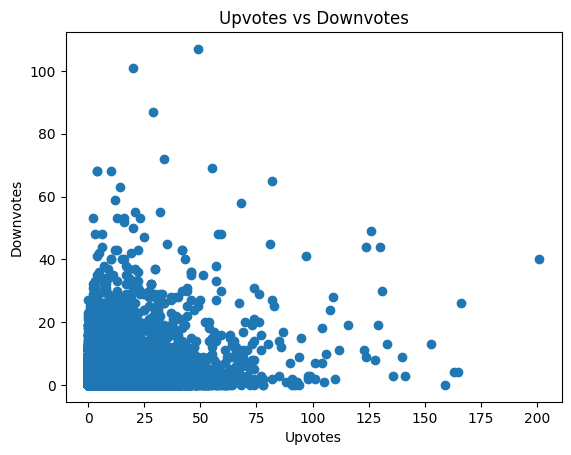

In [14]:
plt.scatter(train['upvote'], train['downvote'])
plt.title("Upvotes vs Downvotes")
plt.xlabel("Upvotes")
plt.ylabel("Downvotes")
plt.show()

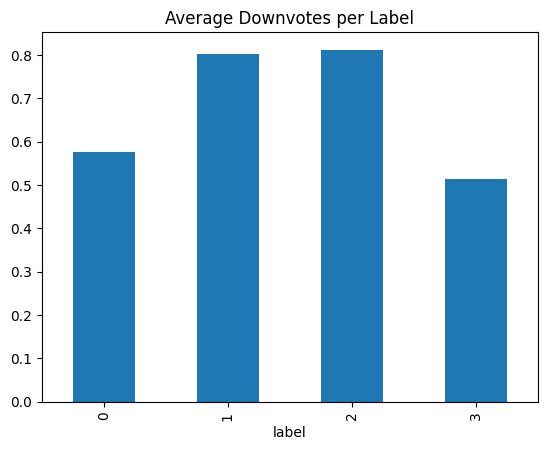

In [15]:
train.groupby('label')['downvote'].mean().plot(kind='bar')
plt.title("Average Downvotes per Label")
plt.show()

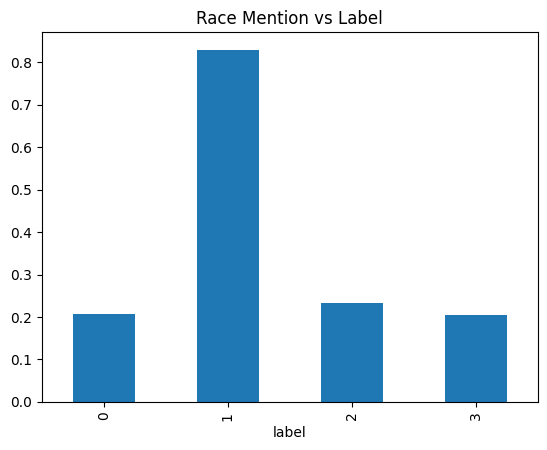

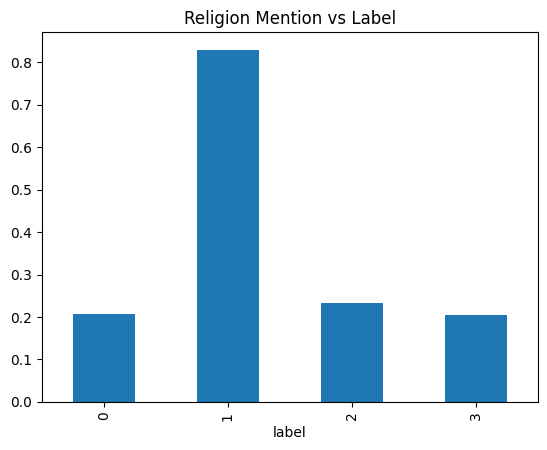

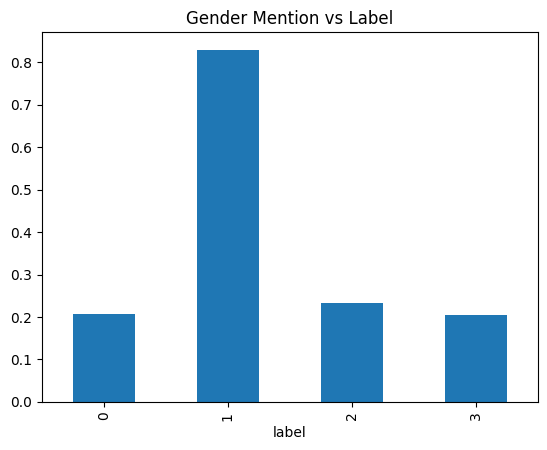

In [16]:
train.groupby('label')['race'].mean().plot(kind='bar')
plt.title("Race Mention vs Label")
plt.show()

train.groupby('label')['religion'].mean().plot(kind='bar')
plt.title("Religion Mention vs Label")
plt.show()

train.groupby('label')['gender'].mean().plot(kind='bar')
plt.title("Gender Mention vs Label")
plt.show()

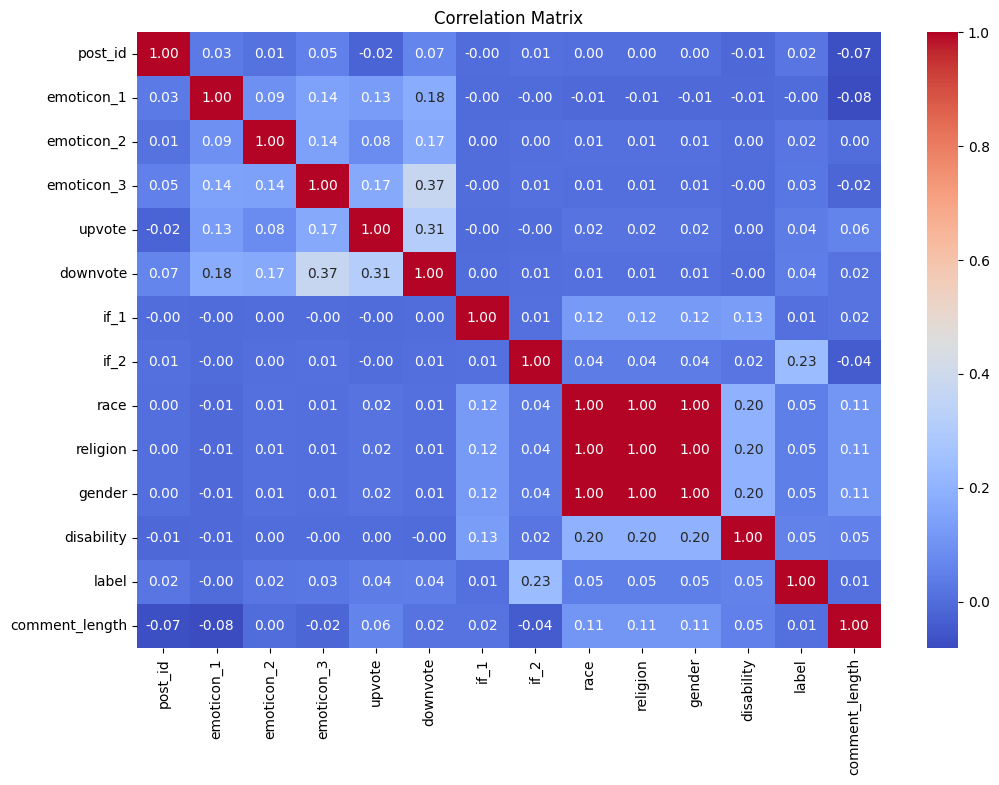

In [17]:
num_cols = train.select_dtypes(include=['int64', 'float64'])

corr = num_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## 6. Text Preprocessing

| case | syntax | Reason |
|------|-----------|--------|
| Lowercase | `text.lower()` | case fixxing  |
| Remove URLs | `re.sub(r"http\S+", ...)` | URLs carry no  signal |
| Remove digits | `re.sub(r"\d+", ...)` | Numbers are rarely informative |
| Remove punctuation | `str.maketrans(...)` | removing punctuations |
| Strip whitespace | `.strip()` | Clean |

In [18]:
#  Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove URLs
    text = re.sub(r"\d+", "", text)           # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.strip()
    return text

train['comment'] = train['comment'].fillna("").apply(clean_text)
test['comment'] = test['comment'].fillna("").apply(clean_text)

## 7. Feature Engineering


| Feature | Formula | need|
|---------|---------|--------|
| `total_votes` | upvote + downvote | total engagement of the post |
| `vote_ratio` | upvote / (total_votes + 1) |  |
| `vote_diff` | upvote − downvote | sentiments of the post |
| `comment_length` | `len(comment)` | longer comments |
| `word_count` | `len(comment.split())` | more words |




In [19]:
# Feature Engineering
train['total_votes'] = train['upvote'] + train['downvote']
test['total_votes'] = test['upvote'] + test['downvote']

train['vote_ratio'] = train['upvote'] / (train['total_votes'] + 1)
test['vote_ratio'] = test['upvote'] / (test['total_votes'] + 1)

train['comment_length'] = train['comment'].apply(len)
test['comment_length'] = test['comment'].apply(len)

train['word_count'] = train['comment'].apply(lambda x: len(str(x).split()))
test['word_count'] = test['comment'].apply(lambda x: len(str(x).split()))


train['vote_diff'] = train['upvote'] - train['downvote']
test['vote_diff'] = test['upvote'] - test['downvote']

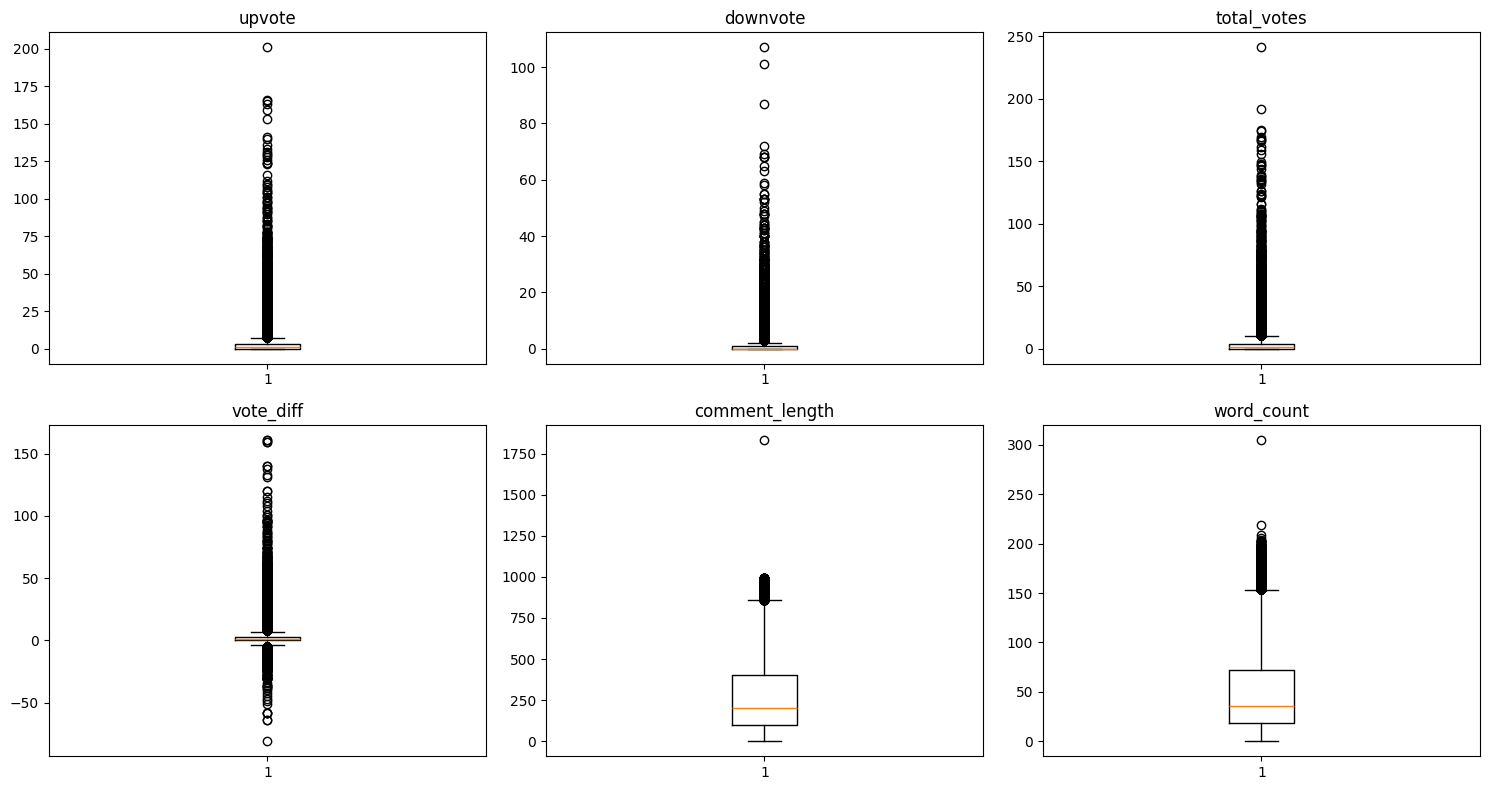

In [20]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cols = ['upvote', 'downvote', 'total_votes', 'vote_diff', 'comment_length', 'word_count']

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(train[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [21]:
cols = ['upvote', 'downvote', 'comment_length', 'word_count']

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR
    train[col] = np.where(train[col] > upper, upper, train[col])

## 8. TF-IDF Vectorization.

| Parameter | Value | Reason |
|-----------|-------|-----------|
| `max_features` | 15,000 | Cap vocabulary to avoid noise & memory issues |
| `ngram_range` | (1, 2) | Capture single words AND two-word phrases (lijke "hate speech") |
| `stop_words` | english | english common words like the a is |
| `min_df` | 3 | Ignore very rare terms (likely typos/noise) |
| `max_df` | 0.9 | Ignore terms appearing in >90% of docs (too common to discriminate) |


In [22]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=3,
    max_df=0.9
)

X_text_train = tfidf.fit_transform(train['comment'])
X_text_test = tfidf.transform(test['comment'])

## 9. Numerical Scaling & Feature Combination

### Scaling
`StandardScaler`   normalises the numerical features.  

### Combining Features
used `scipy.sparse.hstack` to join:
- TF-IDF sparse matrix (15,000 text features)
- Scaled numerical feature matrix (17 structured features)


In [23]:
# Numerical Features
features = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'if_1', 'if_2',
    'race', 'religion', 'gender', 'disability',
    'hour', 'total_votes', 'vote_ratio',
    'vote_diff',
    'comment_length', 'word_count'
]

X_num_train = train[features].values
X_num_test = test[features].values

In [24]:
#  Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)

In [25]:
# Combine Features
from scipy.sparse import hstack

X_train = hstack([X_text_train, X_num_train]).tocsr()
X_test = hstack([X_text_test, X_num_test]).tocsr()

y = train['label']

In [26]:

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 11. Model Training 

I trained and evaluated 3 models 

### Model 1 — Logistic Regression

In [27]:
# Logistic Regression CV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced' , max_iter=3000)

lr_scores = []

for train_idx, val_idx in skf.split(X_train, y):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    lr.fit(X_tr, y_tr)
    preds = lr.predict(X_val)

    score = f1_score(y_val, preds, average='macro')
    lr_scores.append(score)

print("Logistic CV Score:", np.mean(lr_scores))

Logistic CV Score: 0.7807941887262296


### Model 2 — Multinomial Naive Bayes



In [28]:
# Naive Bayes CV

nb_scores = []

for train_idx, val_idx in skf.split(X_text_train, y):
    X_tr, X_val = X_text_train[train_idx], X_text_train[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    nb = MultinomialNB()
    nb.fit(X_tr, y_tr)

    preds = nb.predict(X_val)

    score = f1_score(y_val, preds, average='macro')
    nb_scores.append(score)

print("NB CV Score:", np.mean(nb_scores))

NB CV Score: 0.4914983014015763


### Model 3 — LightGBM (Gradient Boosted Trees)



In [29]:
#  LightGBM CV
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score
import numpy as np

lgb_scores = []

for train_idx, val_idx in skf.split(X_train, y):

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_model = LGBMClassifier(
        random_state=42)

    lgb_model.fit(X_tr, y_tr)

    preds = lgb_model.predict(X_val)

    score = f1_score(y_val, preds, average='macro')
    lgb_scores.append(score)

print("LGBM CV Score:", np.mean(lgb_scores))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 17.661226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 806102
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 15015
[LightGBM] [Info] Start training from score -0.550561
[LightGBM] [Info] Start training from score -2.520763
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.024131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 805877
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 15015
[LightGBM] [Info] Start training from score -0.550561
[LightGBM] [Info] Start training from score -2.520763
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 17.962225 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 806322
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 15013
[LightGBM] [Info] Start training from score -0.550550
[LightGBM] [Info] Start training from score -2.520842
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 17.606833 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 807080
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 15016
[LightGBM] [Info] Start training from score -0.550550
[LightGBM] [Info] Start training from score -2.520842
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 17.995276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 808066
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 15015
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520848
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.588988


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM CV Score: 0.7918641941005976


In [30]:
# Model Performance Comparison

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "LightGBM"],
    "F1 Score": [lr_scores, nb_scores, lgb_scores]
})

print(comparison)

print("\nBest Model:", comparison.sort_values("F1 Score", ascending=False).iloc[0]["Model"])

                 Model                                           F1 Score
0  Logistic Regression  [0.7813130936003339, 0.784895766402203, 0.7765...
1          Naive Bayes  [0.49713882186633895, 0.49109764325195393, 0.4...
2             LightGBM  [0.78737151438281, 0.7929527750764087, 0.79258...

Best Model: LightGBM


## 12. LightGBM Hyperparameter Tuning

I used **RandomizedSearchCV** to tune LightGBM's key hyperparameters:

| Parameter | Tuned Range | Effect |
|-----------|-------------|--------|
| `n_estimators` | 300, 500 | More trees result in  better fit, but risk overfitting |
| `learning_rate` | 0.03, 0.05 | Lower rate result in  more conservative, often better generalisation |
| `num_leaves` | 64, 128 | Controls tree complexity (higher = more complex) |
| `subsample` | 0.8 | Row subsampling results in reducing overfitting |
| `colsample_bytree` | 0.8 | Feature subsampling per tree |
| `reg_alpha/lambda` | 0.5 | L1/L2 regularisation to prevent overfitting |


In [31]:
# LightGBM Hyperparameter Tuning
param_dist = {
    'n_estimators':      [300, 500],
    'learning_rate':     [0.03, 0.05],
    'num_leaves':        [64, 128],
    'subsample':         [0.8],
    'colsample_bytree':  [0.8],
    'reg_alpha':         [0.5],
    'reg_lambda':        [0.5],
    'max_depth':         [-1],
}

tuner = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
search = RandomizedSearchCV(
    tuner, param_dist,
    n_iter=5,
    cv=2,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y)   

print("Best Params:", search.best_params_)
best_params = search.best_params_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 45.867963 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 563953
[LightGBM] [Info] Number of data points in the train set: 98999, number of used features: 14173
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 68.857378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 563953
[LightGBM] [Info] Number of data points in the train set: 98999, number of used features: 14173
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Star

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 26.155670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 943042
[LightGBM] [Info] Number of data points in the train set: 197999, number of used features: 15017
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 47.480300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566193
[LightGBM] [Info] Number of data points in the train set: 99000, number of used features: 14206
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Sta

In [32]:
# LightGBM with Tuned Params

from sklearn.model_selection import train_test_split

X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train, y, test_size=0.2, stratify=y, random_state=42
)

lgb_model = lgb.LGBMClassifier(**best_params, random_state=42)
lgb_model.fit(X_tr_final, y_tr_final)
y_pred_lgb = lgb_model.predict(X_val_final)

print("LGB Tuned Accuracy:", accuracy_score(y_val_final, y_pred_lgb))
print("LGB Tuned F1:      ", f1_score(y_val_final, y_pred_lgb, average='macro'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 21.575364 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 805825
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 15016
[LightGBM] [Info] Start training from score -0.550550
[LightGBM] [Info] Start training from score -2.520842
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB Tuned Accuracy: 0.9126010101010101
LGB Tuned F1:       0.8083004646847478


In [33]:
# Submission
test_preds = lgb_model.predict(X_test)
sample['label'] = test_preds

sample.to_csv("submission.csv", index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
